In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

import datetime
from datetime import timedelta

import calendar
from dateutil.relativedelta import relativedelta


from sklearn.metrics import mean_squared_error

plt.style.use('fivethirtyeight')
color_pal =  sns.color_palette()

import warnings
warnings.filterwarnings('ignore')

<Axes: title={'center': 'Peregrinos por año'}, xlabel='ds'>

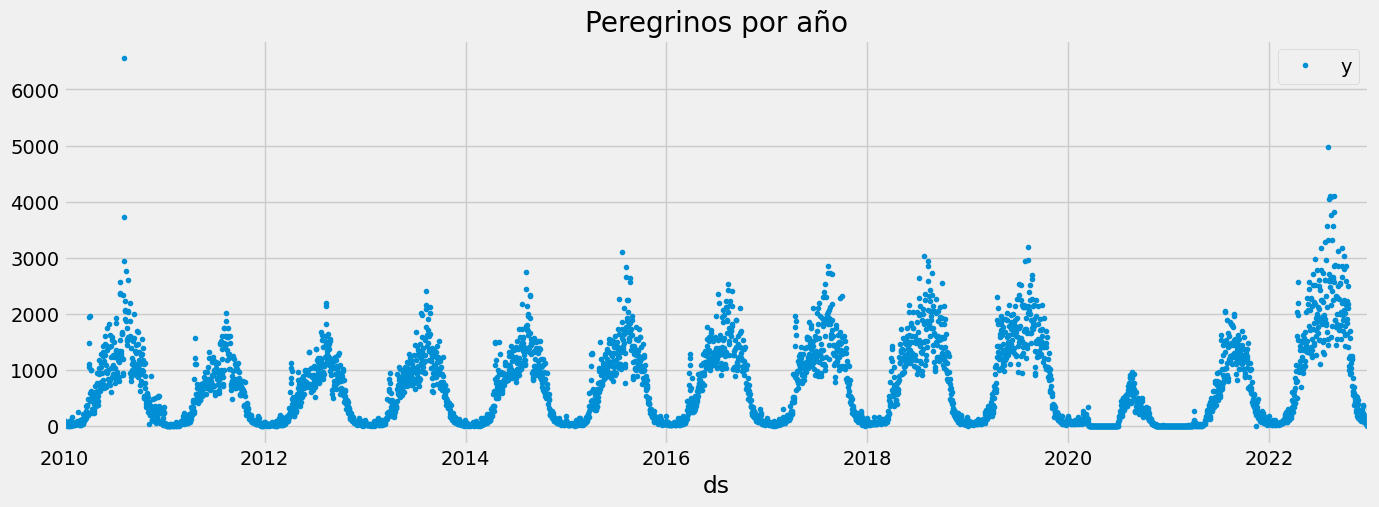

In [3]:
df = pd.read_csv('peregrinos_para_prophet.csv')
df = df.drop(columns='Unnamed: 0')
df = df.set_index('ds')
df.index = pd.to_datetime(df.index)


df.plot(style='.',figsize=(15,5) , color = color_pal[0] ,title='Peregrinos por año')

### Train / Test Split 

In [4]:
df_20 = df.loc[df.index <'2020-01-01']

In [5]:
def soplit_tt(df,fecha):
    df = df.copy()
    #df = df.loc[df.index <'2020-01-01']
    train = df.loc[df.index < fecha ]
    test = df.loc[df.index >= fecha ]
    return train, test

In [6]:
train = df_20.loc[df_20.index <'2019-01-01']
test = df_20.loc[df_20.index >='2019-01-01']

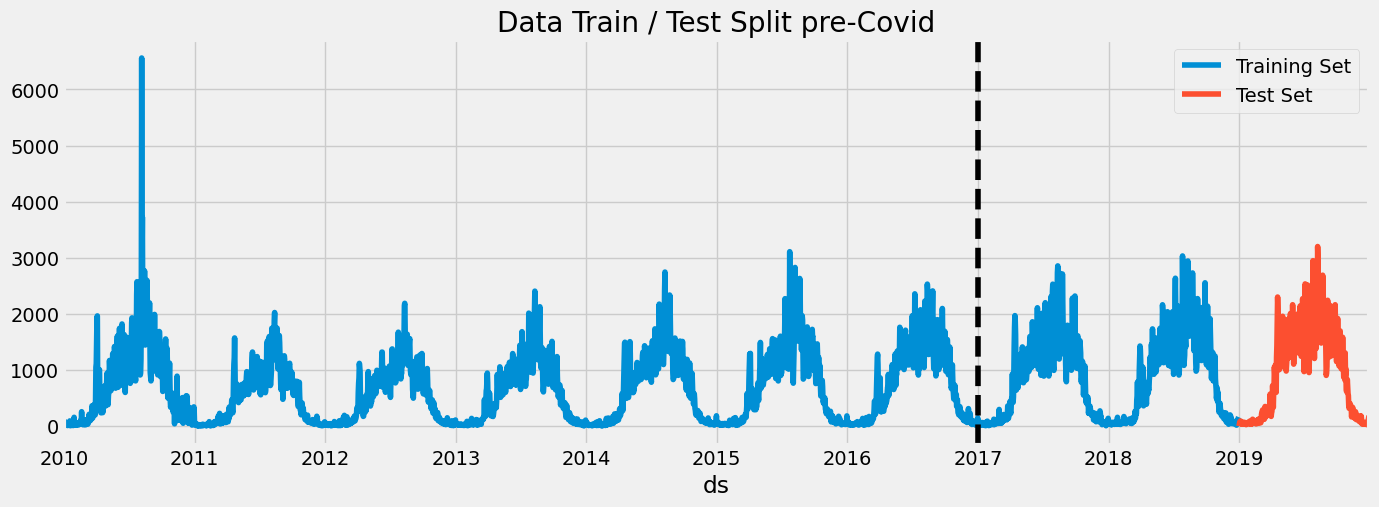

In [7]:
fig, ax = plt.subplots(figsize=(15,5))

train.plot(ax=ax, label='Training set', title= 'Data Train / Test Split pre-Covid' )
test.plot(ax=ax, label= 'Test set' )
ax.axvline('2017-01-01', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

<Axes: xlabel='ds'>

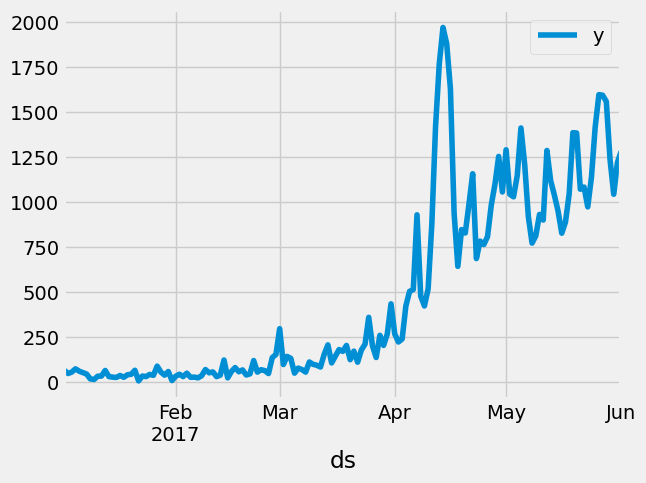

In [8]:
df_20.loc[(df_20.index >'2017-01-01') & (df_20.index<='2017-06-01')].plot()

<Axes: xlabel='ds'>

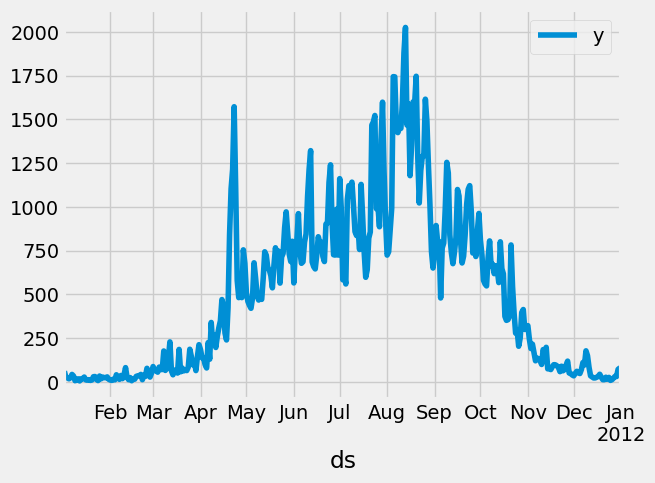

In [9]:
df_20.loc[(df_20.index >'2011-01-01') & (df_20.index<='2012-01-01')].plot()

<Axes: xlabel='ds'>

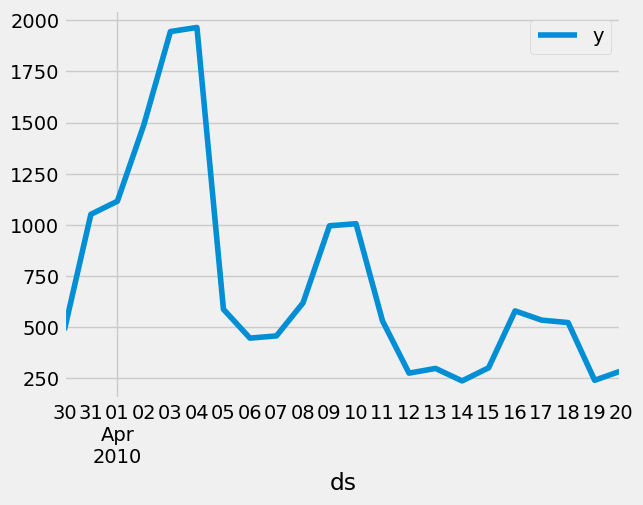

In [10]:
df_20.loc[(df_20.index >'2010-03-29') & (df_20.index<='2010-04-20')].plot()

In [11]:
def add_time_features(df):
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df





In [12]:
def add_lags_day(df):
    target_map = df['y'].to_dict()
    df['lag1'] = df.index.map(lambda x: target_map.get(x - pd.DateOffset(days=365) if (x - pd.DateOffset(days=364)).day == 29 and (x - pd.DateOffset(days=364)).month == 2 else x - pd.DateOffset(days=364)))
    df['lag2'] = df.index.map(lambda x: target_map.get(x - pd.DateOffset(days=730) if (x - pd.DateOffset(days=728)).day == 29 and (x - pd.DateOffset(days=728)).month == 2 else x - pd.DateOffset(days=728)))
    df['lag3'] = df.index.map(lambda x: target_map.get(x - pd.DateOffset(days=1096) if (x - pd.DateOffset(days=1092)).day == 29 and (x - pd.DateOffset(days=1092)).month == 2 else x - pd.DateOffset(days=1092)))
    return df




In [13]:
df_20_t = add_lags_day(add_time_features(df_20))

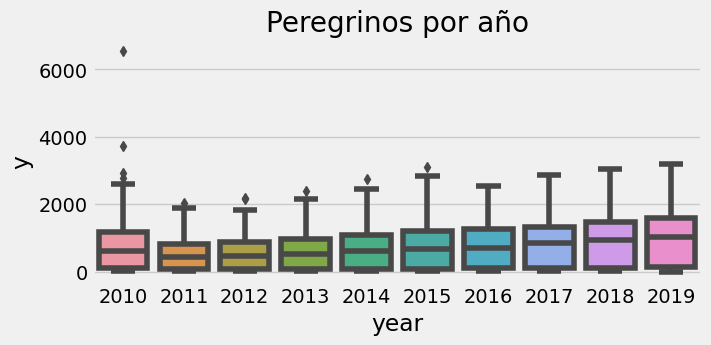

In [14]:
fig, ax = plt.subplots(figsize=(7,3))

sns.boxplot( data = df_20_t, x = 'year', y= 'y')
ax.set_title('Peregrinos por año')
plt.show()

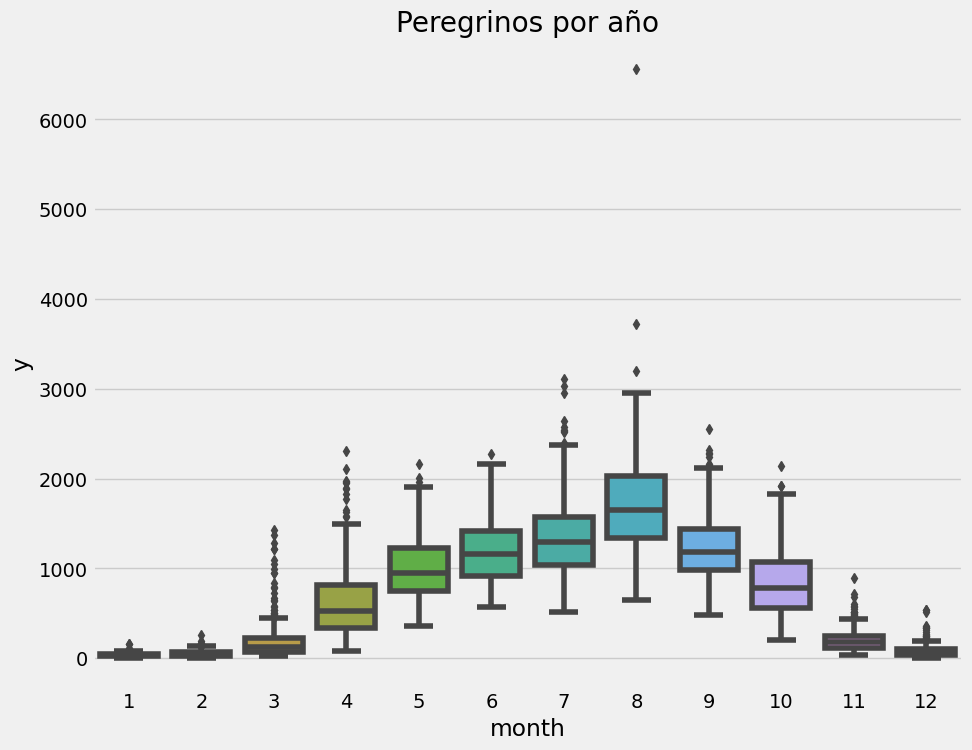

In [15]:
fig, ax = plt.subplots(figsize=(10,8))

sns.boxplot( data = df_20_t, x = 'month', y= 'y')
ax.set_title('Peregrinos por año')
plt.show()

In [16]:
def xacobeo_add(df):
    df = df.copy()

    xacobeo = pd.DataFrame({'ds': pd.date_range(start='2010-01-01', end='2022-12-31')})
    xacobeo['xacobeo'] = 0
    xacobeo.loc[xacobeo['ds'].isin(pd.date_range(start='2010-01-01', end='2010-12-31')), 'xacobeo'] = 1
    xacobeo.loc[xacobeo['ds'].isin(pd.date_range(start='2021-01-01', end='2022-12-31')), 'xacobeo'] = 1
    xacobeo = xacobeo.set_index('ds')
    xacobeo.index = pd.to_datetime(xacobeo.index)

    df = pd.merge(df, xacobeo, left_index=True, right_index=True, how='left')
    df['xacobeo'] = df['xacobeo'].fillna(0).astype(int)
    
    return df


In [17]:
def confinamiento_add(df):
    df = df.copy()

    confinamiento = pd.DataFrame({'ds': pd.date_range(start='2010-01-01', end='2022-12-31')})
    confinamiento['confinamiento'] = 0
    confinamiento.loc[confinamiento['ds'].isin(pd.date_range(start='2020-03-14', end='2020-06-21')), 'confinamiento'] = 1


    confinamiento = confinamiento.set_index('ds')
    confinamiento.index = pd.to_datetime(confinamiento.index)

    df = pd.merge(df, confinamiento, left_index=True, right_index=True, how='left')
    df['confinamiento'] = df['confinamiento'].fillna(0).astype(int)
    
    return df


In [18]:
def restriccion(df):
    df = df.copy()

    restriccion = pd.DataFrame({'ds': pd.date_range(start='2010-01-01', end='2022-12-31')})
    restriccion['restriccion'] = 0
    restriccion.loc[restriccion['ds'].isin(pd.date_range(start='2020-10-09', end='2021-05-08')), 'restriccion'] = 1

    restriccion = restriccion.set_index('ds')
    restriccion.index = pd.to_datetime(restriccion.index)

    df = pd.merge(df, restriccion, left_index=True, right_index=True, how='left')
    df['restriccion'] = df['restriccion'].fillna(0).astype(int)
    
    return df


In [19]:
def apostol_add(df):
    df = df.copy()
    fechas = []

    for year in range(2010, 2024):
        fecha = datetime.date(year, 7, 25)

        if fecha.weekday() == 6:
            # El día de Santiago coincide con un domingo
            sabado = fecha - datetime.timedelta(days=1)
            viernes = sabado - datetime.timedelta(days=1)
            fechas.append(viernes)
            fechas.append(sabado)
            fechas.append(fecha)
        else:
            # Buscamos el domingo siguiente
            domingo_siguiente = fecha + datetime.timedelta(days=(6 - fecha.weekday()))
            sabado = domingo_siguiente - datetime.timedelta(days=1)
            viernes = sabado - datetime.timedelta(days=1)
            fechas.append(viernes)
            fechas.append(sabado)
            fechas.append(domingo_siguiente)

    apostol =pd.DataFrame()
    apostol['ds'] =fechas
    apostol['apostol']= 1 


    apostol = apostol.set_index('ds')
    apostol.index = pd.to_datetime(apostol.index)

    df = pd.merge(df, apostol, left_index=True, right_index=True, how='left')
    df['apostol'] = df['apostol'].fillna(0).astype(int)
    return df

In [83]:
def añadir_festivos(df):
    df = df.copy()

    festivos = pd.DataFrame({'ds': pd.date_range(start='2010-01-01', end='2023-12-31')})
    festivos['festivo'] = 0

    festivos.loc[(festivos['ds'].dt.month == 1) & (festivos['ds'].dt.day == 1), 'festivo'] = 1  # 1 de enero
    festivos.loc[(festivos['ds'].dt.month == 4) & (festivos['ds'].dt.day == 2), 'festivo'] = 1  # 2 de abril
    festivos.loc[(festivos['ds'].dt.month == 4) & (festivos['ds'].dt.day == 23), 'festivo'] = 1  # 23 de abril
    festivos.loc[(festivos['ds'].dt.month == 5) & (festivos['ds'].dt.day == 1), 'festivo'] = 1  # 1 de mayo
    festivos.loc[(festivos['ds'].dt.month == 8) & (festivos['ds'].dt.day == 15), 'festivo'] = 1  # 15 de agosto
    festivos.loc[(festivos['ds'].dt.month == 10) & (festivos['ds'].dt.day == 12), 'festivo'] = 1  # 12 de octubre
    festivos.loc[(festivos['ds'].dt.month == 11) & (festivos['ds'].dt.day == 1), 'festivo'] = 1  # 1 de noviembre
    festivos.loc[(festivos['ds'].dt.month == 12) & (festivos['ds'].dt.day == 6), 'festivo'] = 1  # 6 de diciembre
    festivos.loc[(festivos['ds'].dt.month == 12) & (festivos['ds'].dt.day == 8), 'festivo'] = 1  # 8 de diciembre
    festivos.loc[(festivos['ds'].dt.month == 12) & (festivos['ds'].dt.day == 25), 'festivo'] = 1  # 25 de diciembre

    festivos = festivos.set_index('ds')
    festivos.index = pd.to_datetime(festivos.index)

    df = pd.merge(df, festivos, left_index=True, right_index=True, how='left')
    df['festivo'] = df['festivo'].fillna(0).astype(int)
    
    return df


In [84]:
def añadir_festivos23(df):
    df = df.copy()

    festivos = pd.DataFrame({'ds': pd.date_range(start='2010-01-01', end='2023-12-31')})
    festivos['festivo'] = 0

    festivos.loc[(festivos['ds'].dt.month == 1) & (festivos['ds'].dt.day == 1), 'festivo'] = 1  # 1 de enero
    festivos.loc[(festivos['ds'].dt.month == 4) & (festivos['ds'].dt.day == 2), 'festivo'] = 1  # 2 de abril
    festivos.loc[(festivos['ds'].dt.month == 4) & (festivos['ds'].dt.day == 23), 'festivo'] = 1  # 23 de abril
    festivos.loc[(festivos['ds'].dt.month == 5) & (festivos['ds'].dt.day == 1), 'festivo'] = 1  # 1 de mayo
    festivos.loc[(festivos['ds'].dt.month == 8) & (festivos['ds'].dt.day == 15), 'festivo'] = 1  # 15 de agosto
    festivos.loc[(festivos['ds'].dt.month == 10) & (festivos['ds'].dt.day == 12), 'festivo'] = 1  # 12 de octubre
    festivos.loc[(festivos['ds'].dt.month == 11) & (festivos['ds'].dt.day == 1), 'festivo'] = 1  # 1 de noviembre
    festivos.loc[(festivos['ds'].dt.month == 12) & (festivos['ds'].dt.day == 6), 'festivo'] = 1  # 6 de diciembre
    festivos.loc[(festivos['ds'].dt.month == 12) & (festivos['ds'].dt.day == 8), 'festivo'] = 1  # 8 de diciembre
    festivos.loc[(festivos['ds'].dt.month == 12) & (festivos['ds'].dt.day == 25), 'festivo'] = 1  # 25 de diciembre

    festivos = festivos.set_index('ds')
    festivos.index = pd.to_datetime(festivos.index)

    df = pd.merge(df, festivos, left_index=True, right_index=True, how='left')
    df['festivo'] = df['festivo'].fillna(0).astype(int)
    
    return df



In [75]:
def puente(df):
    df = df.copy()

    puente = pd.DataFrame({'ds': pd.date_range(start='2010-01-01', end='2024-12-31')})
    puente['puente'] = 0

    puente = puente.set_index('ds')
    puente.index = pd.to_datetime(puente.index)

    df = pd.merge(df, puente, left_index=True, right_index=True, how='left')

    df['puente'] = (((df['festivo'] == 1) & ((df.index.weekday == 4) | (df.index.weekday == 0))) |
                   ((df['festivo'].shift(1) == 1) & (df.index.weekday == 5)) |
                   ((df['festivo'].shift(2) == 1) & (df.index.weekday == 6)) |
                   ((df['festivo'].shift(-1) == 1) & (df.index.weekday == 6)) |
                   ((df['festivo'].shift(-2) == 1) & (df.index.weekday == 5))).astype(int)

    return df


In [76]:
def santa(df):
    df = df.copy()

    santa = pd.DataFrame({'ds': pd.date_range(start='2010-01-01', end='2022-12-31')})
    santa['santa'] = 0

    santa = santa.set_index('ds')
    santa.index = pd.to_datetime(santa.index)

    df = pd.merge(df, santa, left_index=True, right_index=True, how='left')

    df['santa'] = ((df.index >= pd.to_datetime('2010-03-28')) & (df.index <= pd.to_datetime('2010-04-04'))) | \
                  ((df.index >= pd.to_datetime('2011-04-17')) & (df.index <= pd.to_datetime('2011-04-24'))) | \
                  ((df.index >= pd.to_datetime('2012-04-01')) & (df.index <= pd.to_datetime('2012-04-09'))) | \
                  ((df.index >= pd.to_datetime('2013-03-24')) & (df.index <= pd.to_datetime('2013-03-31'))) | \
                  ((df.index >= pd.to_datetime('2014-04-13')) & (df.index <= pd.to_datetime('2014-04-21'))) | \
                  ((df.index >= pd.to_datetime('2015-03-29')) & (df.index <= pd.to_datetime('2015-04-06'))) | \
                  ((df.index >= pd.to_datetime('2016-03-20')) & (df.index <= pd.to_datetime('2016-03-28'))) | \
                  ((df.index >= pd.to_datetime('2017-04-09')) & (df.index <= pd.to_datetime('2017-04-17'))) | \
                  ((df.index >= pd.to_datetime('2018-03-25')) & (df.index <= pd.to_datetime('2018-04-02'))) | \
                  ((df.index >= pd.to_datetime('2019-04-14')) & (df.index <= pd.to_datetime('2019-04-22'))) | \
                  ((df.index >= pd.to_datetime('2020-04-05')) & (df.index <= pd.to_datetime('2020-04-13'))) | \
                  ((df.index >= pd.to_datetime('2021-03-28')) & (df.index <= pd.to_datetime('2021-04-05'))) | \
                  ((df.index >= pd.to_datetime('2022-04-10')) & (df.index <= pd.to_datetime('2022-04-18')))  | \
                  ((df.index >= pd.to_datetime('2023-04-02')) & (df.index <= pd.to_datetime('2022-04-09')))

    df['santa'] = df['santa'].astype(int)

    return df


In [23]:
df_20_x =  add_time_features(
                santa(
                restriccion(
                    puente(
                        añadir_festivos(
                                    apostol_add(
                                        confinamiento_add(
                                            xacobeo_add(df_20))))))))

In [24]:
df_20_x.loc[df_20_x.puente==1].head(1)

,y,xacobeo,confinamiento,apostol,festivo,puente,restriccion,santa,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
ds,,,,,,,,,,,,,,,
2010-01-01,115,1,0,0,1,1,0,0,4,1,1,2010,1,1,53


In [25]:
df_20.head(1)

,y
ds,
2010-01-01,115


In [26]:
train = df_20_x.loc[df_20_x.index <'2019-01-01']
test = df_20.loc[df_20_x.index >='2019-01-01']

In [27]:
train, test = soplit_tt(df_20_x,'2018-01-01')

In [28]:
train.weekofyear = train.weekofyear.astype(int)
test.weekofyear = test.weekofyear.astype(int)



In [29]:
train.columns

Index(['y', 'xacobeo', 'confinamiento', 'apostol', 'festivo', 'puente',
       'restriccion', 'santa', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear', 'dayofmonth', 'weekofyear'],
      dtype='object')

In [30]:
train

,y,xacobeo,confinamiento,apostol,festivo,puente,restriccion,santa,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
ds,,,,,,,,,,,,,,,
2010-01-01,115,1,0,0,1,1,0,0,4,1,1,2010,1,1,53
2010-01-02,53,1,0,0,0,1,0,0,5,1,1,2010,2,2,53
2010-01-03,25,1,0,0,0,1,0,0,6,1,1,2010,3,3,53
2010-01-04,70,1,0,0,0,0,0,0,0,1,1,2010,4,4,1
2010-01-05,56,1,0,0,0,0,0,0,1,1,1,2010,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-27,42,0,0,0,0,0,0,0,2,4,12,2017,361,27,52
2017-12-28,44,0,0,0,0,0,0,0,3,4,12,2017,362,28,52
2017-12-29,63,0,0,0,0,0,0,0,4,4,12,2017,363,29,52


## Create Model

In [31]:


FEATURES = ['xacobeo', 'confinamiento', 'apostol', 'festivo', 'puente',
       'restriccion', 'santa', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear', 'dayofmonth', 'weekofyear']

TARGET = 'y'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [32]:
reg = xgb.XGBRegressor(base_score= 0.5, booster='gbtree',    
                       n_estimators= 4500,
                       early_stopping_rounds= 75 ,
                       objective='reg:linear',
                       max_depth= 6 ,
                       learning_rate=0.008)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[18:35:14] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation_0-rmse:896.92989	validation_1-rmse:1192.48185
[100]	validation_0-rmse:450.30024	validation_1-rmse:688.25365
[200]	validation_0-rmse:259.40741	validation_1-rmse:451.86282
[300]	validation_0-rmse:182.19377	validation_1-rmse:331.07699
[400]	validation_0-rmse:143.03581	validation_1-rmse:273.82064
[500]	validation_0-rmse:124.80823	validation_1-rmse:240.18521
[600]	validation_0-rmse:114.07533	validation_1-rmse:222.81016
[700]	validation_0-rmse:106.46804	validation_1-rmse:213.05649
[800]	validation_0-rmse:100.08707	validation_1-rmse:207.55572
[900]	validation_0-rmse:93.20078	validation_1-rmse:203.06780
[1000]	validation_0-rmse:86.55945	validation_1-rmse:199.54295
[1100]	validation_0-rmse:82.92786	validation_1-rmse:197.80560
[1200]	validation_0-rmse:79.66993	validation

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=75,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.008, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=4500, n_jobs=None, num_parallel_tree=None,
             objective='reg:linear', predictor=None, ...)

In [33]:
fi = pd.DataFrame(data= reg.feature_importances_,
            index=reg.feature_names_in_,
            columns = ['importance'])
fi.sort_values('importance', ascending = False)

,importance
quarter,0.568546
dayofyear,0.188873
santa,0.113516
weekofyear,0.027232
xacobeo,0.026156
dayofweek,0.024479
year,0.019252
dayofmonth,0.008593
month,0.008433
apostol,0.008358


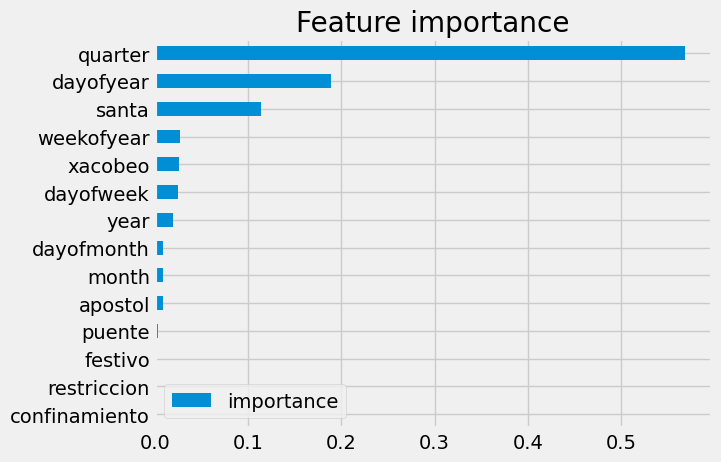

In [34]:
fi.sort_values('importance').plot(kind = 'barh', title = 'Feature importance')
plt.show()

# Forecast on Test

In [35]:
test['prediction'] = reg.predict(X_test)
df_20_x = df_20_x.merge(test[['prediction']], how='left', left_index=True, right_index=True )

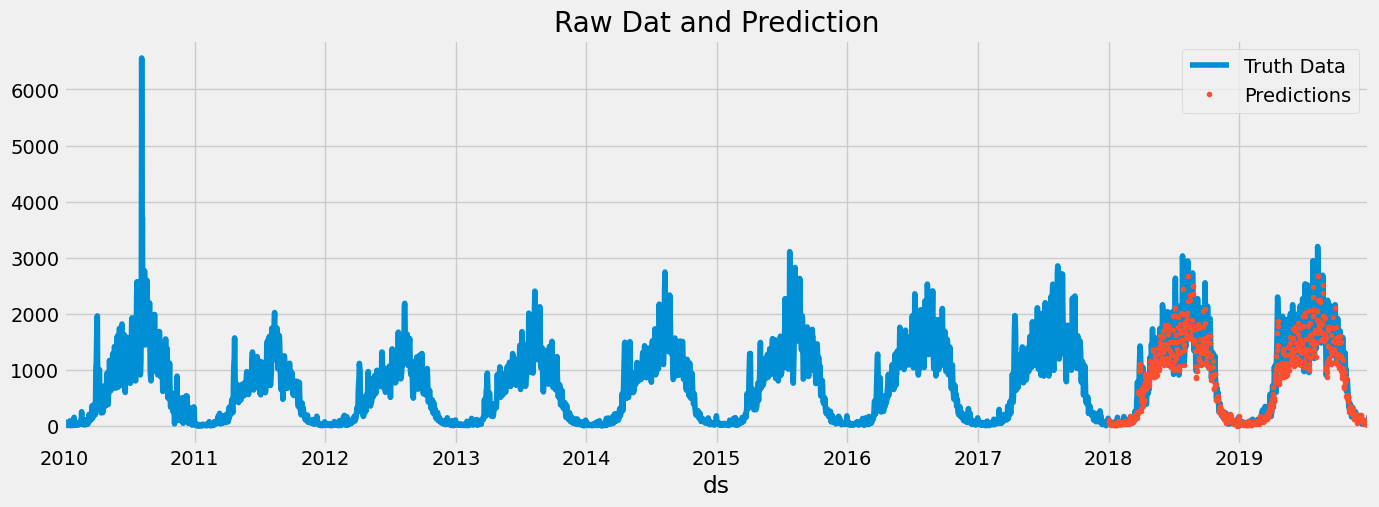

In [36]:
ax = df_20_x[['y']].plot(figsize=(15, 5))
df_20_x['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

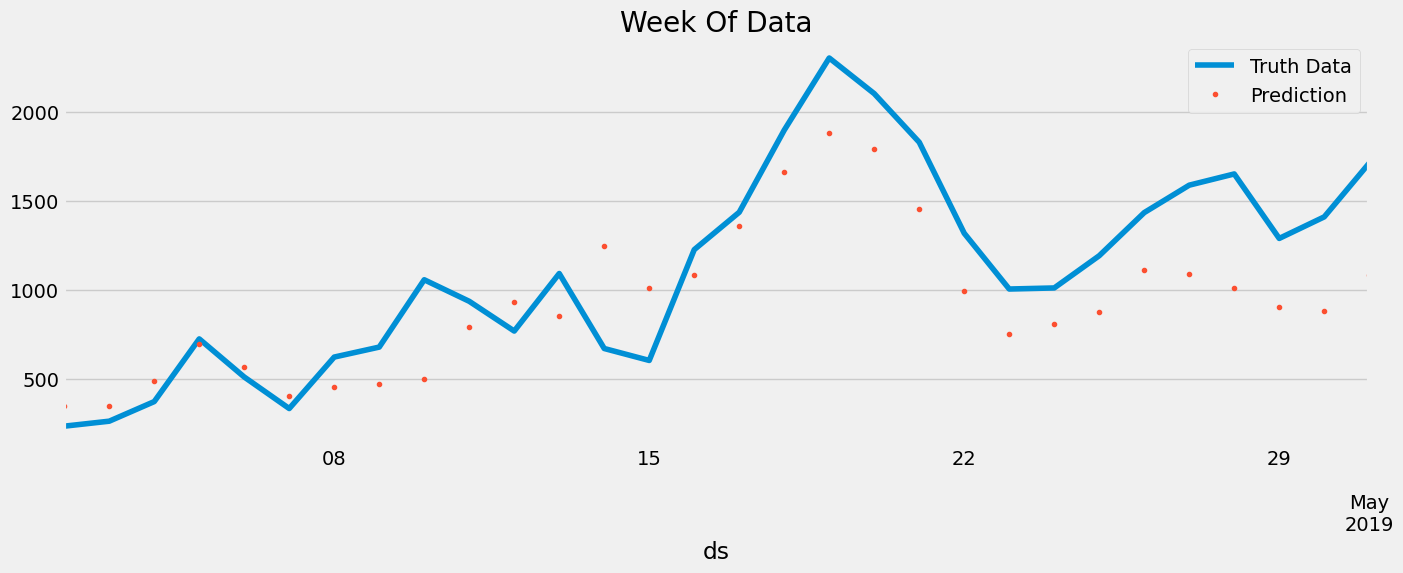

In [37]:
ax = df_20_x.loc[(df_20_x.index >'2019-04-01')  & (df_20_x.index <='2019-05-01')]['y'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df_20_x.loc[(df_20_x.index > '04-01-2019') & (df_20_x.index <='2019-05-01')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

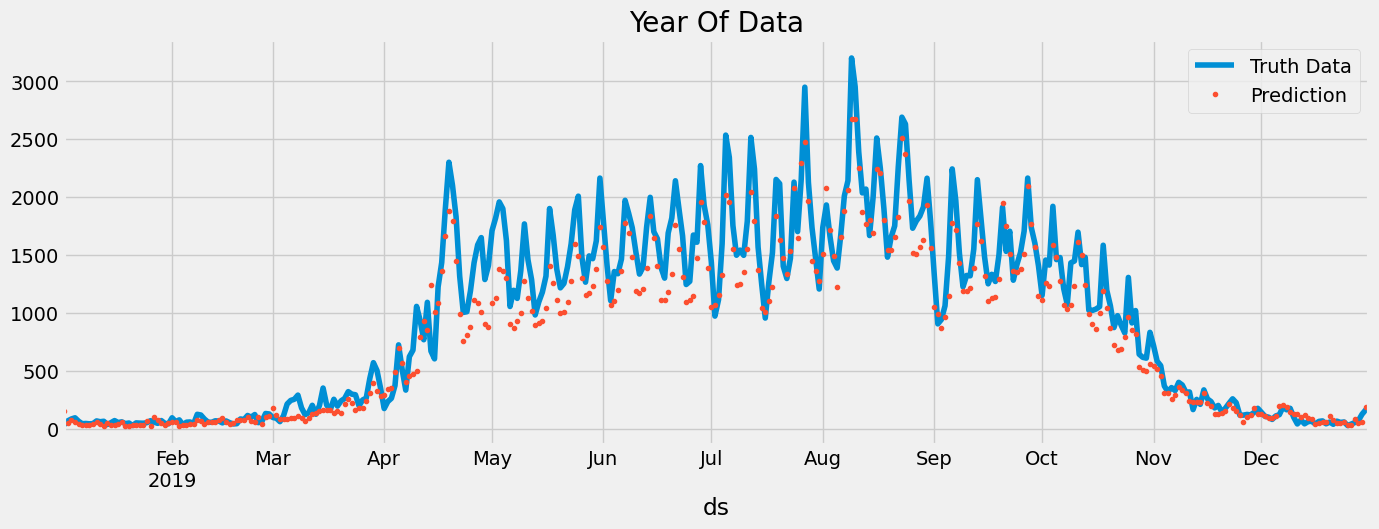

In [38]:
ax = df_20_x.loc[(df_20_x.index >'2019-01-01')  & (df_20_x.index <='2019-12-31')]['y'] \
    .plot(figsize=(15, 5), title='Year Of Data')
df_20_x.loc[(df_20_x.index > '2019-01-01') & (df_20_x.index <='2019-12-31')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

# Score (RMSE)

In [39]:
score = np.sqrt(mean_squared_error(test['y'], test['prediction']*1.25))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 209.78


# Calculate Error

In [40]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(10)

date
2018-04-01    890.887909
2019-05-02    694.066650
2018-07-07    650.043091
2019-04-28    642.875610
2019-05-01    629.739380
2018-07-27    594.239746
2019-05-03    581.189209
2019-04-14    573.761597
2018-08-09    567.919312
2019-04-10    555.788391
Name: error, dtype: float64

In [41]:
test.groupby(['date'])['error'].mean().sort_values(ascending=True).head(10)

date
2019-02-07    0.383186
2018-12-09    0.496292
2018-01-31    0.613499
2019-02-21    0.683357
2018-07-15    0.732178
2018-02-20    0.809067
2019-11-25    0.909729
2019-02-11    0.920803
2018-11-14    0.941193
2018-01-05    1.013893
Name: error, dtype: float64

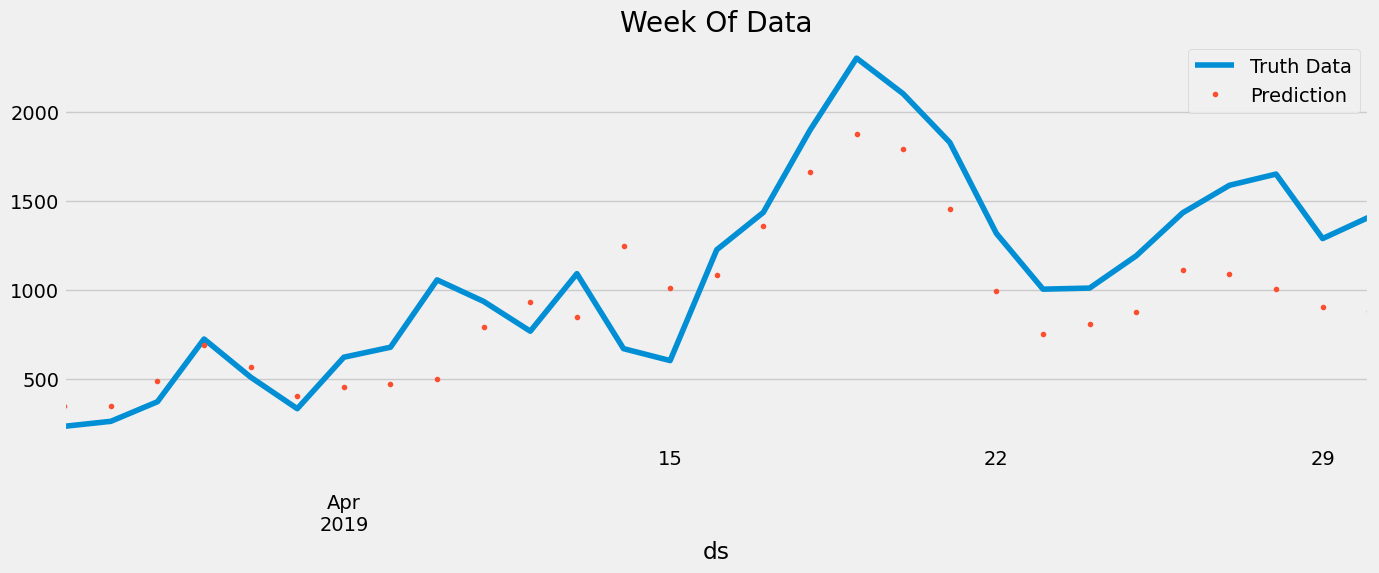

In [42]:
ax = df_20_x.loc[(df_20_x.index >'2019-04-01')  & (df_20_x.index <='2019-04-30')]['y'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df_20_x.loc[(df_20_x.index > '2019-04-01') & (df_20_x.index <='2019-04-30')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

# Time Series Cross Validation

In [43]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=4, test_size=365, gap=1)


In [44]:
df = pd.read_csv('peregrinos_para_prophet.csv')
df = df.drop(columns='Unnamed: 0')
df = df.set_index('ds')
df.index = pd.to_datetime(df.index)



In [45]:
df = df.loc[df.index <'2020-01-01']

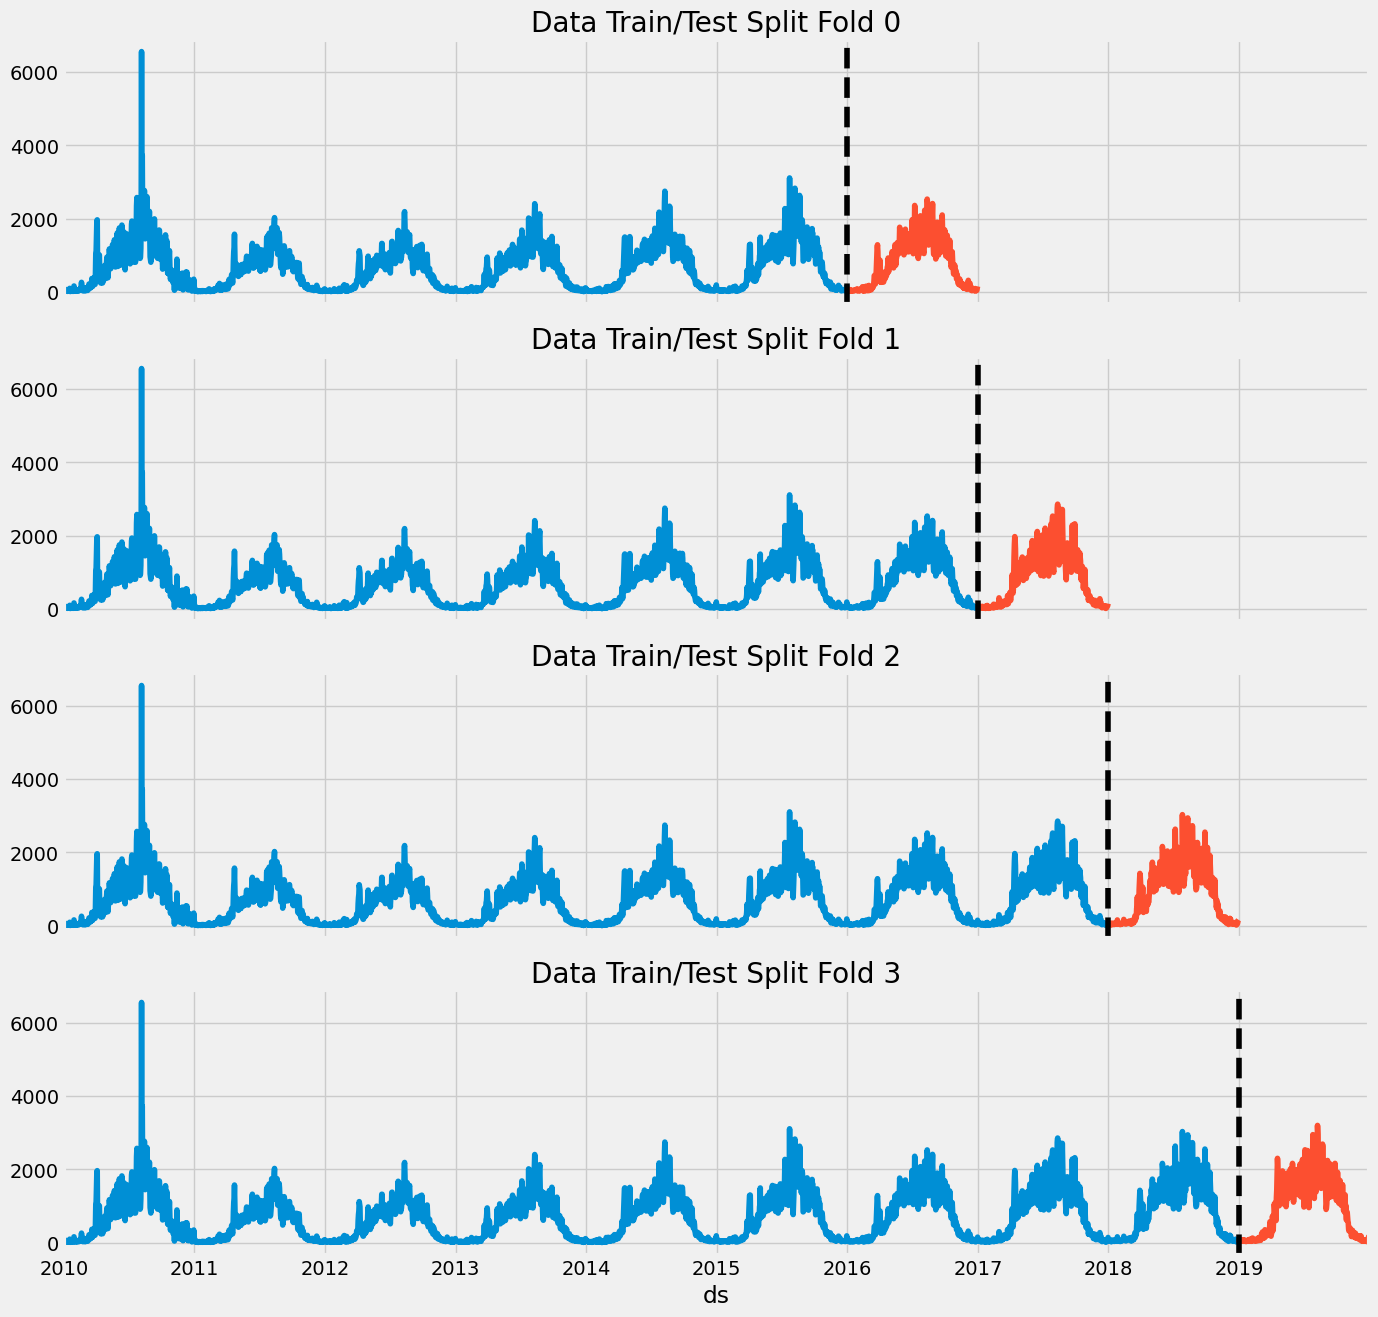

In [46]:
fig, axs = plt.subplots(4, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['y'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['y'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

In [47]:
df = add_time_features(df)

In [48]:
df = add_lags_day(df)
df[(df.weekofyear==1) & (df.year==2017)].head()

,y,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3
ds,,,,,,,,,,,
2017-01-02,67,0,1,1,2017,2,2,1,38.0,52.0,19.0
2017-01-03,49,1,1,1,2017,3,3,1,74.0,66.0,26.0
2017-01-04,57,2,1,1,2017,4,4,1,54.0,28.0,11.0
2017-01-05,75,3,1,1,2017,5,5,1,21.0,25.0,21.0
2017-01-06,62,4,1,1,2017,6,6,1,45.0,43.0,27.0


In [49]:
df = restriccion(puente(añadir_festivos(xacobeo_add(confinamiento_add(apostol_add(df))))))
df.columns

Index(['y', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'apostol', 'confinamiento',
       'xacobeo', 'festivo', 'puente', 'restriccion'],
      dtype='object')

In [50]:
df = santa(df)

In [51]:
df.columns

Index(['y', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'apostol', 'confinamiento',
       'xacobeo', 'festivo', 'puente', 'restriccion', 'santa'],
      dtype='object')

In [52]:
df.weekofyear = df.weekofyear.astype(int)

# Train Using Cross Validation

In [53]:
tss = TimeSeriesSplit(n_splits=4, test_size=365, gap=1)


fold = 0
preds = []
scores = []
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1500,
                       early_stopping_rounds=60,
                       objective='reg:linear',
                       max_depth= 6,
                       learning_rate=0.008)

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    FEATURES = [ 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'apostol', 'confinamiento',
       'xacobeo', 'festivo', 'puente', 'restriccion', 'santa']
    TARGET = 'y'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]


    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[18:35:47] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation_0-rmse:847.23085	validation_1-rmse:989.27582
[100]	validation_0-rmse:424.68544	validation_1-rmse:498.09059
[200]	validation_0-rmse:244.93599	validation_1-rmse:277.88162
[300]	validation_0-rmse:167.58411	validation_1-rmse:189.73781
[400]	validation_0-rmse:135.09711	validation_1-rmse:156.64002
[500]	validation_0-rmse:118.52706	validation_1-rmse:146.62256
[600]	validation_0-rmse:106.02289	validation_1-rmse:144.34352
[651]	validation_0-rmse:101.62271	validation_1-rmse:144.48629
[18:35:48] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation_0-rmse:868.83209	validation_1-rmse:1073.66780
[100]	validation_

In [54]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 174.2618
Fold scores:[144.1781211222062, 184.817539515606, 164.3551094198411, 203.69658513644904]


In [55]:
fi = pd.DataFrame(data= reg.feature_importances_,
            index=reg.feature_names_in_,
            columns = ['importance'])
fi.sort_values('importance', ascending = False)

,importance
lag1,0.540853
santa,0.084443
dayofyear,0.078537
lag3,0.063228
lag2,0.048951
month,0.041372
weekofyear,0.036725
year,0.024373
apostol,0.023295
quarter,0.018302


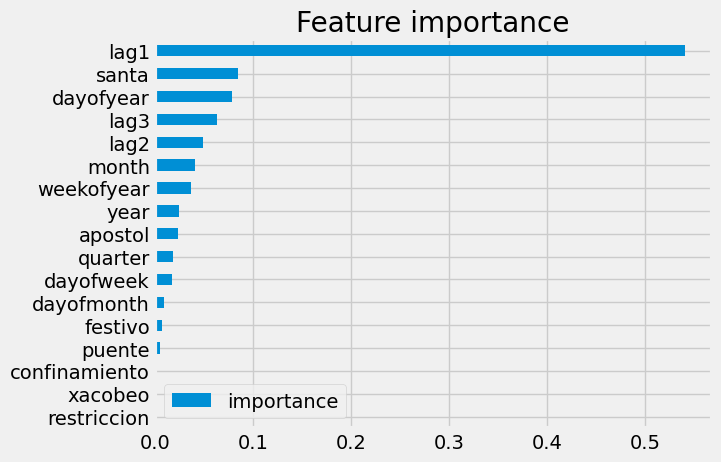

In [56]:
fi.sort_values('importance').plot(kind = 'barh', title = 'Feature importance')
plt.show()

In [57]:
reg.save_model('model_XGB.json')


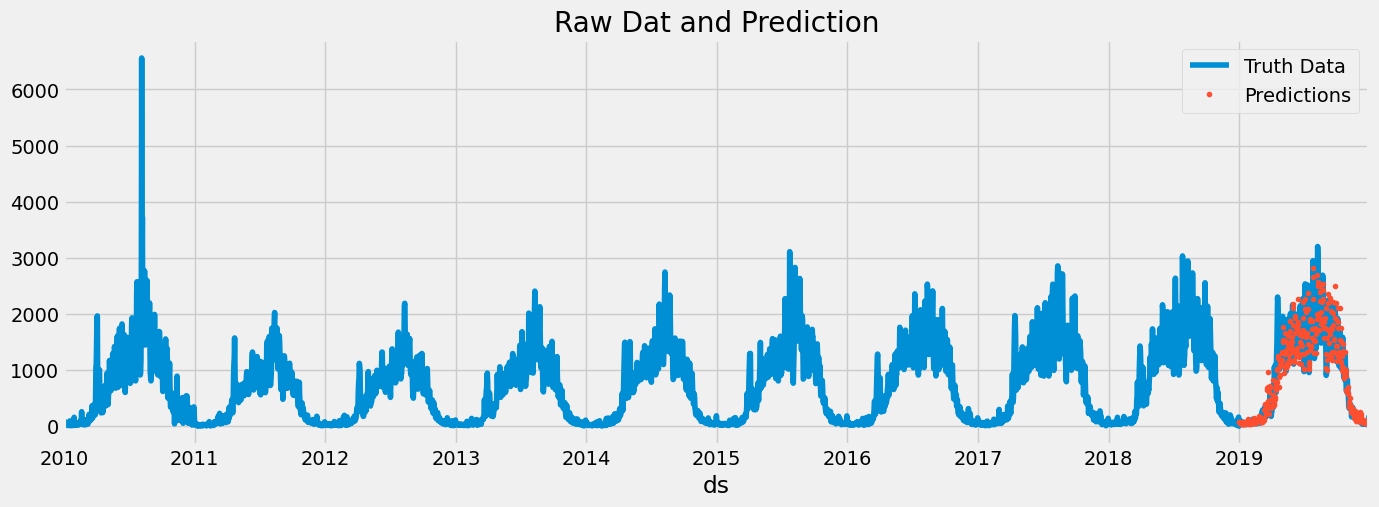

In [58]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True )
ax = df[['y']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

# Vamos a juntar todo

<Axes: title={'center': 'Peregrinos por año'}, xlabel='ds'>

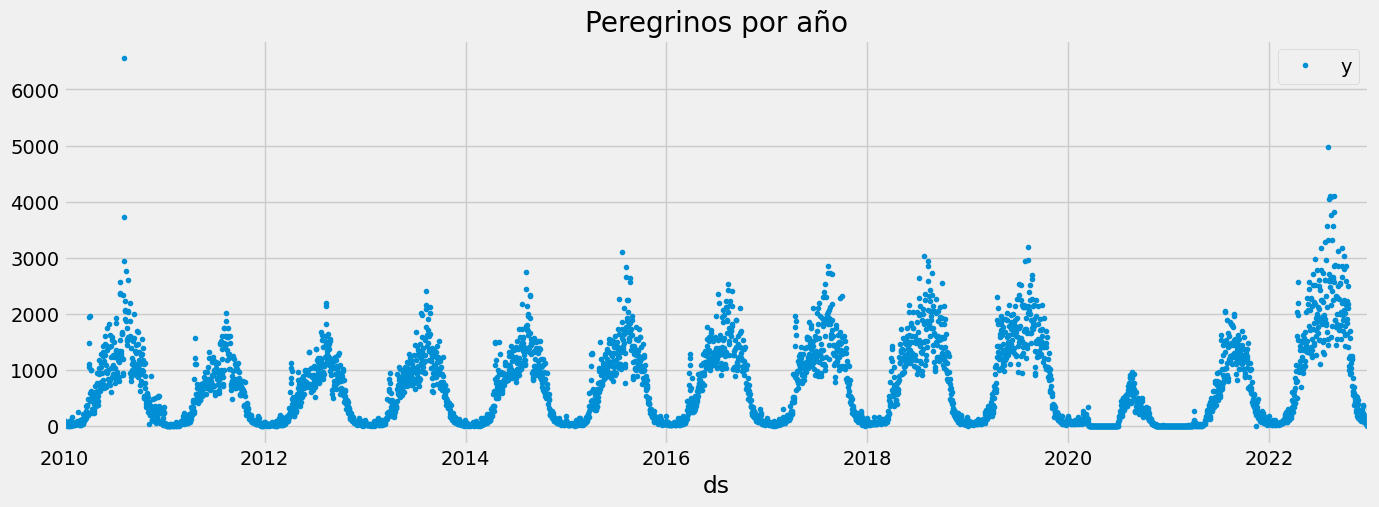

In [59]:
df = pd.read_csv('peregrinos_para_prophet.csv')
df = df.drop(columns='Unnamed: 0')
df = df.set_index('ds')
df.index = pd.to_datetime(df.index)

df.plot(style='.',figsize=(15,5) , color = color_pal[0] ,title='Peregrinos por año')


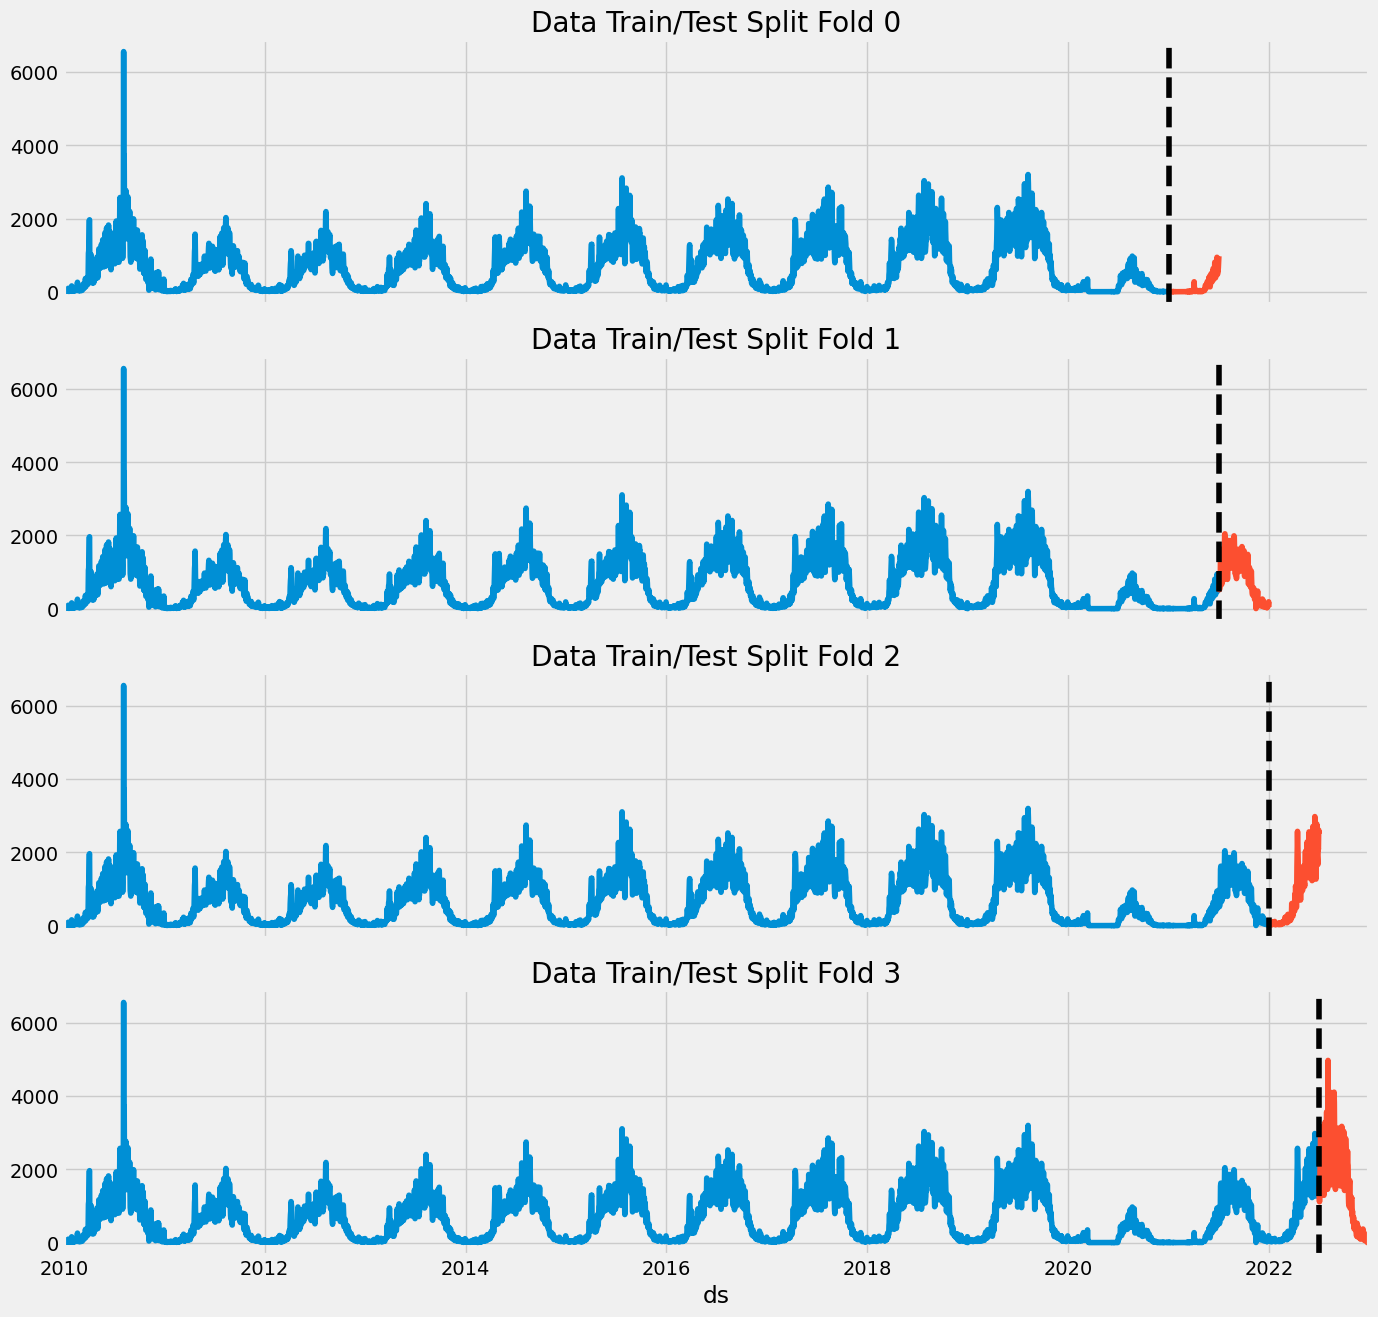

In [60]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=4, test_size=182, gap=1)


fig, axs = plt.subplots(4, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['y'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['y'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

### Añadimos características temporales

In [61]:
df = add_lags_day(add_time_features(df))

### Añadimos caracteristicas festivas

In [62]:
df = santa(restriccion(puente(añadir_festivos(xacobeo_add(confinamiento_add(apostol_add(df)))))))

df.weekofyear = df.weekofyear.astype(int)
df.columns

Index(['y', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'apostol', 'confinamiento',
       'xacobeo', 'festivo', 'puente', 'restriccion', 'santa'],
      dtype='object')

# Train Using Cross Validation

In [63]:
tss = TimeSeriesSplit(n_splits=4, test_size=182, gap=1)


fold = 0
preds = []
scores = []
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=5000,
                       early_stopping_rounds=60,
                       objective='reg:linear',
                       max_depth= 6,
                       learning_rate=0.008)

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    FEATURES = [ 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'apostol', 'confinamiento',
       'xacobeo', 'festivo', 'puente', 'restriccion', 'santa']
    TARGET = 'y'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]


    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[18:36:01] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation_0-rmse:920.82339	validation_1-rmse:249.10386
[72]	validation_0-rmse:548.82285	validation_1-rmse:226.19502
[18:36:02] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/objective/regression_obj.cu:213: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation_0-rmse:902.03131	validation_1-rmse:1022.53322
[100]	validation_0-rmse:446.73168	validation_1-rmse:927.44889
[200]	validation_0-rmse:254.81833	validation_1-rmse:870.77935
[300]	validation_0-rmse:174.11404	validation_1-rmse:805.16404
[400]	validation_0-rmse:139.06292	validation_1-rmse:755.39253
[500]	validation_0-rmse:122.08774	validation_1-rmse:733.57677
[600]	validation_0-rmse:110.98910	validation_1-rmse:721.09267
[700]	validation_0

In [64]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 583.2597
Fold scores:[224.67960163130982, 678.0393237400887, 821.595850003669, 608.7238631047599]


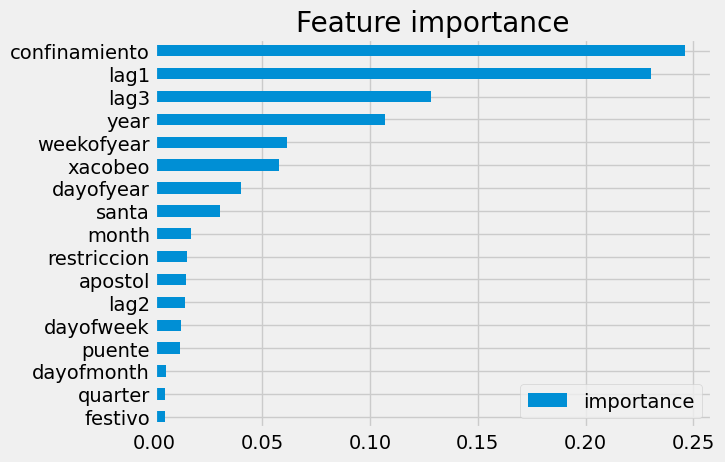

In [65]:
fi = pd.DataFrame(data= reg.feature_importances_,
            index=reg.feature_names_in_,
            columns = ['importance'])

fi.sort_values('importance').plot(kind = 'barh', title = 'Feature importance')
plt.show()

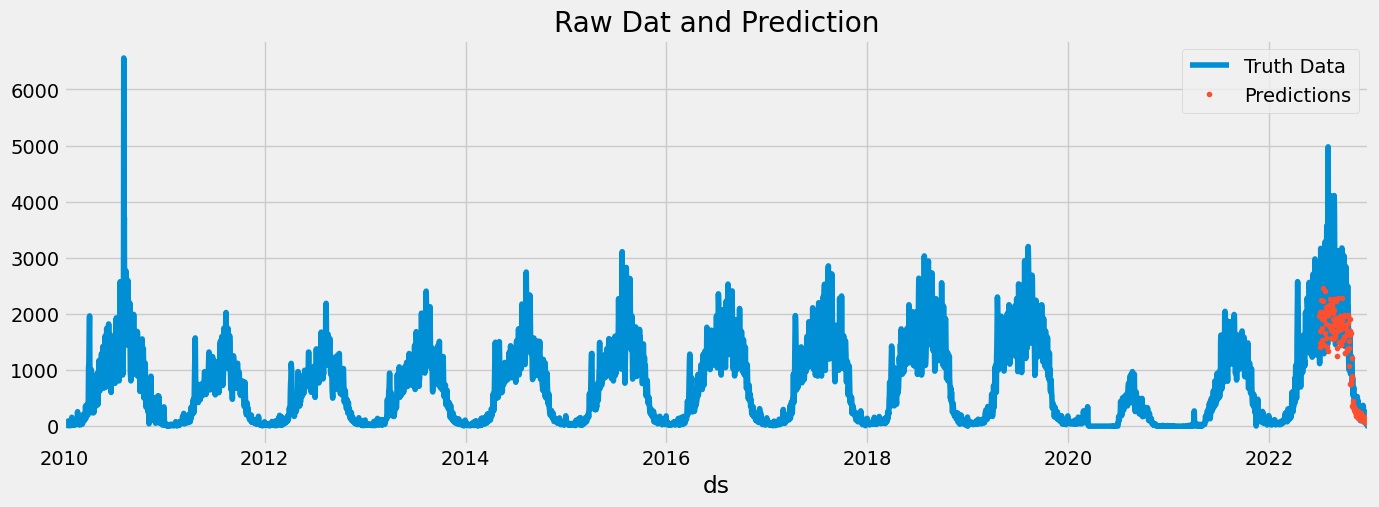

In [66]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True )
ax = df[['y']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

In [85]:
df_23 = pd.DataFrame({'ds': pd.date_range(start='2023-01-01', end='2023-12-31')})
df_23 = df_23.set_index('ds')
df_23.index = pd.to_datetime(df_23.index)
df_23 =   add_time_features(santa(restriccion(puente(añadir_festivos(xacobeo_add(confinamiento_add(apostol_add(df_23))))))))

In [86]:
df_23[df_23.festivo ==1]

,apostol,confinamiento,xacobeo,festivo,puente,restriccion,santa,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
ds,,,,,,,,,,,,,,
2023-01-01,0,0,0,1,0,0,0,6,1,1,2023,1,1,52
2023-04-02,0,0,0,1,0,0,0,6,2,4,2023,92,2,13
2023-04-23,0,0,0,1,0,0,0,6,2,4,2023,113,23,16
2023-05-01,0,0,0,1,1,0,0,0,2,5,2023,121,1,18
2023-08-15,0,0,0,1,0,0,0,1,3,8,2023,227,15,33
2023-10-12,0,0,0,1,0,0,0,3,4,10,2023,285,12,41
2023-11-01,0,0,0,1,0,0,0,2,4,11,2023,305,1,44
2023-12-06,0,0,0,1,0,0,0,2,4,12,2023,340,6,49
2023-12-08,0,0,0,1,1,0,0,4,4,12,2023,342,8,49


In [93]:
def add_lags_day_23(df1, df2):
    df = df1.copy()
    target_map = df['y'].to_dict()
    df2['lag1'] = df2.index.map(lambda x: target_map.get(x - pd.DateOffset(days=365) if (x - pd.DateOffset(days=364)).day == 29 and (x - pd.DateOffset(days=364)).month == 2 else x - pd.DateOffset(days=364)))
    df2['lag2'] = df2.index.map(lambda x: target_map.get(x - pd.DateOffset(days=730) if (x - pd.DateOffset(days=728)).day == 29 and (x - pd.DateOffset(days=728)).month == 2 else x - pd.DateOffset(days=728)))
    df2['lag3'] = df2.index.map(lambda x: target_map.get(x - pd.DateOffset(days=1096) if (x - pd.DateOffset(days=1092)).day == 29 and (x - pd.DateOffset(days=1092)).month == 2 else x - pd.DateOffset(days=1092)))
    return True



In [97]:
add_lags_day_23(df,df_23)
df_23[df_23.lag1.isna()]

,apostol,confinamiento,xacobeo,festivo,puente,restriccion,santa,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3
ds,,,,,,,,,,,,,,,,,
2023-12-31,0,0,0,0,0,0,0,6,4,12,2023,365,31,52,NaN,40,0


In [101]:
df_23.dropna(inplace= True)

In [102]:
df_23[df_23.lag1.isna()]

,apostol,confinamiento,xacobeo,festivo,puente,restriccion,santa,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3
ds,,,,,,,,,,,,,,,,,


# Obvio no tenemos lag1, es la limitacion del modelo, solo podemos predecir 1 año

In [105]:
df_23 = df_23[[ 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'apostol', 'confinamiento',
       'xacobeo', 'festivo', 'puente', 'restriccion', 'santa']]

In [109]:
df_23.weekofyear = df_23.weekofyear.astype(int)

In [110]:
df_23['prediction'] = reg.predict(df_23)



In [112]:
df_23

,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,apostol,confinamiento,xacobeo,festivo,puente,restriccion,santa,prediction
ds,,,,,,,,,,,,,,,,,,
2023-01-01,6,1,1,2023,1,1,52,40.0,0,105,0,0,0,1,0,0,0,120.269478
2023-01-02,0,1,1,2023,2,2,1,45.0,4,76,0,0,0,0,0,0,0,56.125534
2023-01-03,1,1,1,2023,3,3,1,33.0,9,49,0,0,0,0,0,0,0,55.461632
2023-01-04,2,1,1,2023,4,4,1,48.0,3,54,0,0,0,0,0,0,0,60.906799
2023-01-05,3,1,1,2023,5,5,1,81.0,1,67,0,0,0,0,0,0,0,67.237747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-26,1,4,12,2023,360,26,52,69.0,60,2,0,0,0,0,0,0,0,60.987503
2023-12-27,2,4,12,2023,361,27,52,69.0,65,4,0,0,0,0,0,0,0,63.876606
2023-12-28,3,4,12,2023,362,28,52,93.0,123,7,0,0,0,0,0,0,0,90.616371


In [115]:
df1 = df.copy()

In [118]:
df1 = df1[['y', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'apostol', 'confinamiento',
       'xacobeo', 'festivo', 'puente', 'restriccion', 'santa']]

In [121]:
df_concat = pd.concat([df1, df_23])
df_concat

,y,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,apostol,confinamiento,xacobeo,festivo,puente,restriccion,santa,prediction
ds,,,,,,,,,,,,,,,,,,,
2010-01-01,115.0,4,1,1,2010,1,1,53,NaN,NaN,NaN,0,0,1,1,1,0,0,NaN
2010-01-02,53.0,5,1,1,2010,2,2,53,NaN,NaN,NaN,0,0,1,0,1,0,0,NaN
2010-01-03,25.0,6,1,1,2010,3,3,53,NaN,NaN,NaN,0,0,1,0,1,0,0,NaN
2010-01-04,70.0,0,1,1,2010,4,4,1,NaN,NaN,NaN,0,0,1,0,0,0,0,NaN
2010-01-05,56.0,1,1,1,2010,5,5,1,NaN,NaN,NaN,0,0,1,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-26,NaN,1,4,12,2023,360,26,52,69.0,60.0,2.0,0,0,0,0,0,0,0,60.987503
2023-12-27,NaN,2,4,12,2023,361,27,52,69.0,65.0,4.0,0,0,0,0,0,0,0,63.876606
2023-12-28,NaN,3,4,12,2023,362,28,52,93.0,123.0,7.0,0,0,0,0,0,0,0,90.616371


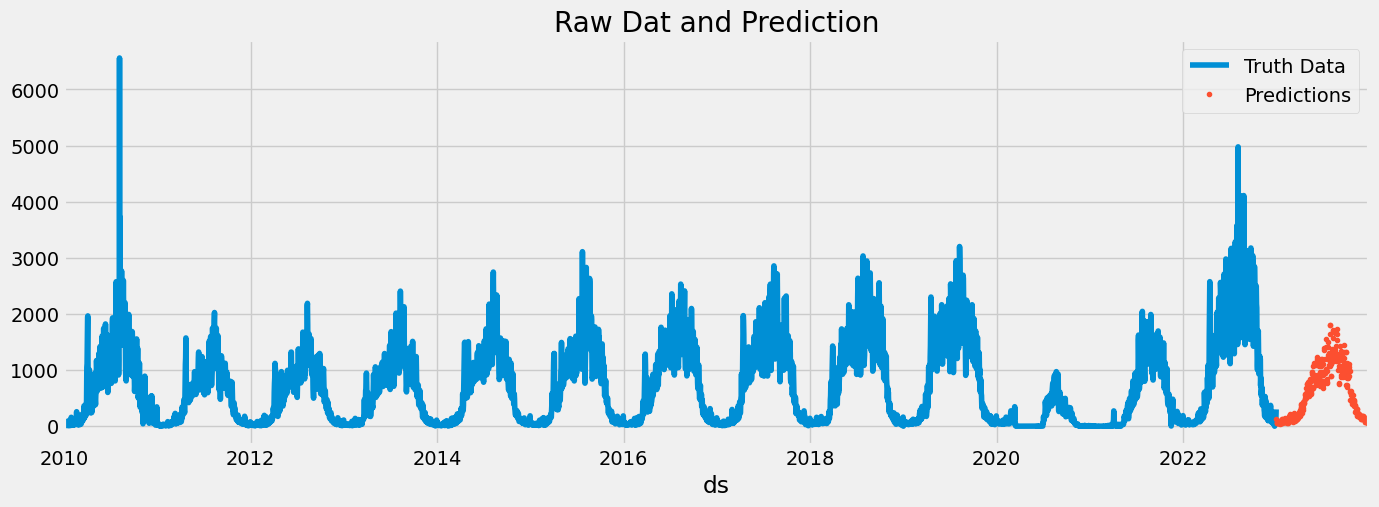

In [122]:
ax = df_concat[['y']].plot(figsize=(15, 5))
df_concat['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

# Prophet model VS XGBoost Model





In [45]:
xgb_out = df.copy()

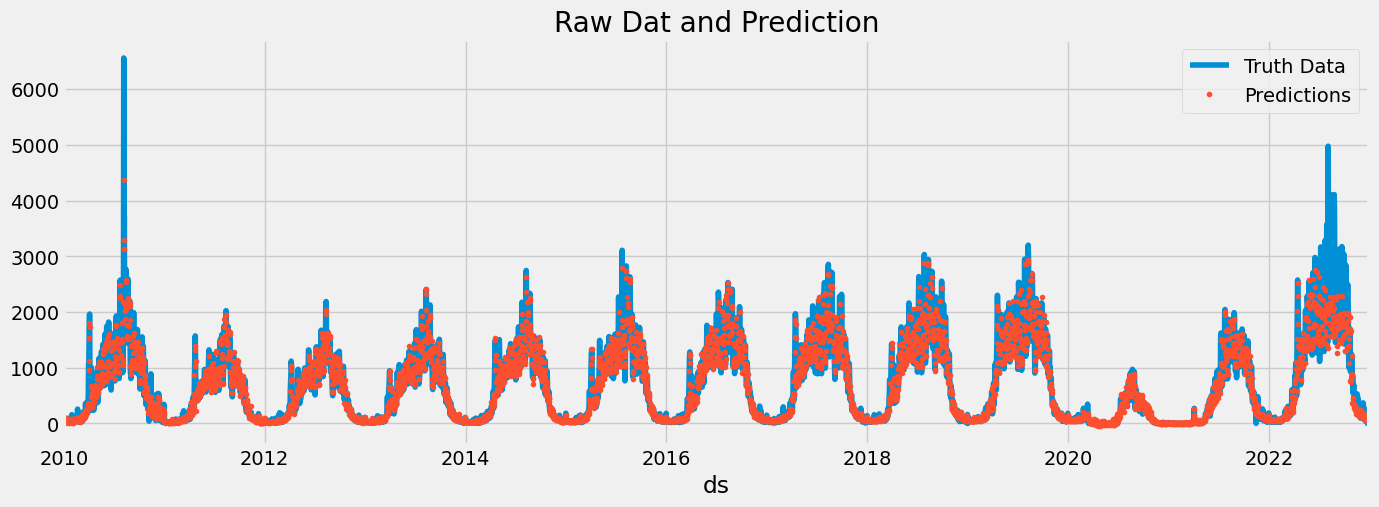

In [47]:
xgb_out['prediction'] = reg.predict(df[['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'apostol', 'confinamiento',
       'xacobeo', 'festivo', 'puente', 'restriccion', 'santa']])
ax = xgb_out[['y']].plot(figsize=(15, 5))
xgb_out['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

<Axes: title={'center': 'Peregrinos por año'}>

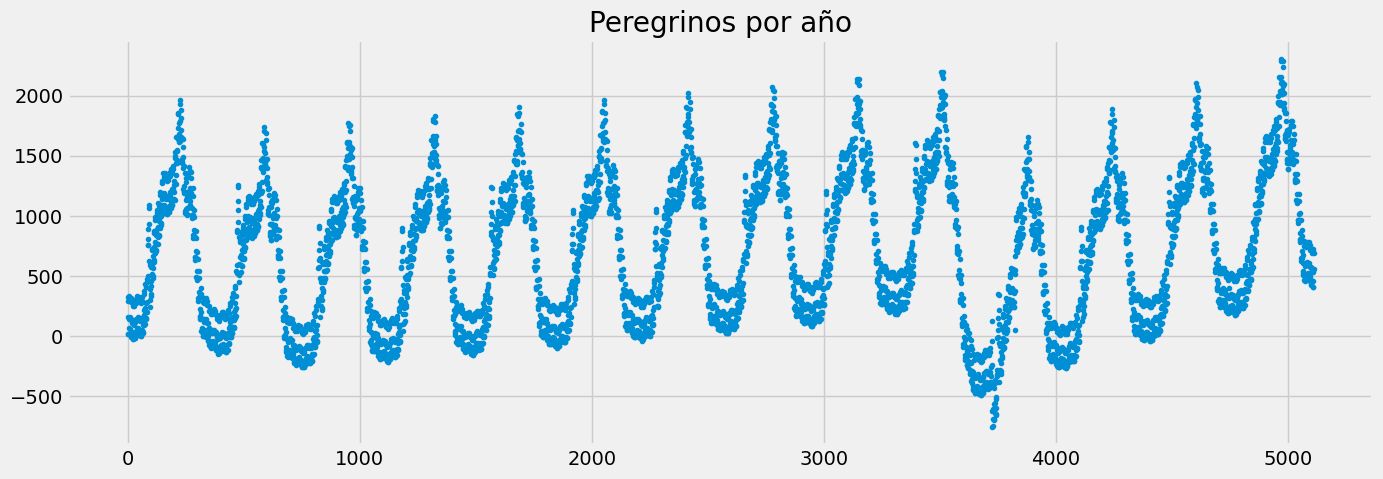

In [42]:
prophet = pd.read_csv('prevision_prophet_f.csv')



prophet['yhat'].plot(style='.',figsize=(15,5) , color = color_pal[0] ,title='Peregrinos por año')

In [52]:
prophet = prophet.drop(columns='Unnamed: 0')
prophet = prophet.set_index('ds')
prophet.index = pd.to_datetime(prophet.index)

prophet = prophet['yhat']

In [53]:
output= pd.concat([prophet,xgb_out], axis =1 )

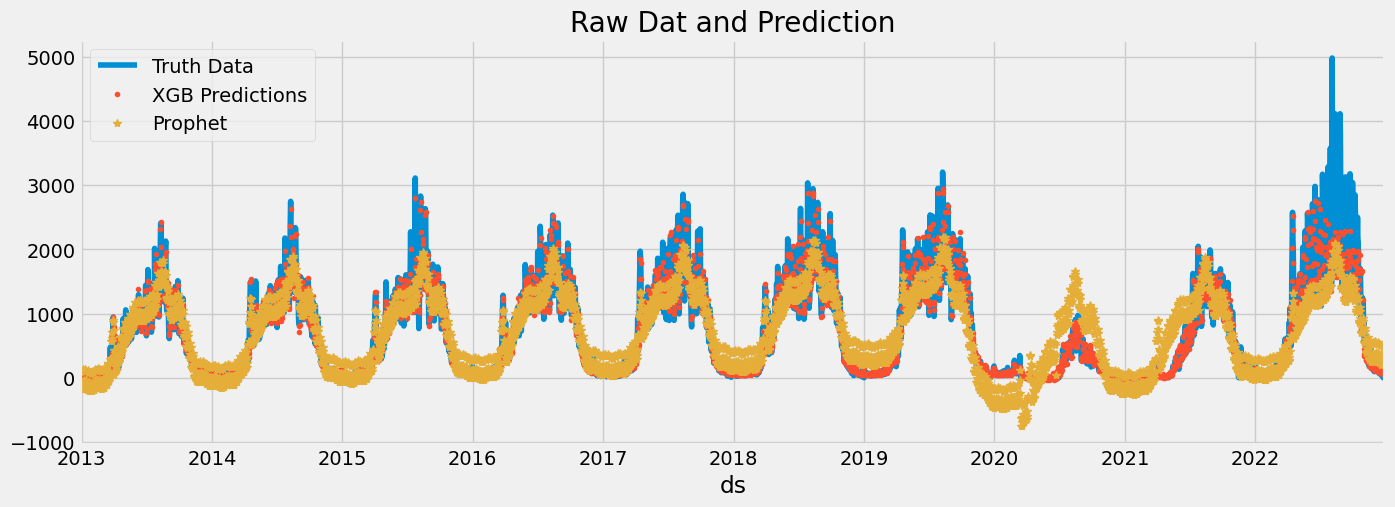

In [56]:
output.dropna(inplace=True)
ax = output[['y']].plot(figsize=(15, 5))
output['prediction'].plot(ax=ax, style='.')
output['yhat'].plot(ax=ax, style='*')


plt.legend(['Truth Data', 'XGB Predictions', 'Prophet'])
ax.set_title('Raw Dat and Prediction')
plt.show()

Nada no hay nada que sacar aqui 

In [65]:
semana_pred = xgb_out[(xgb_out.index > '2022-07-03') & (xgb_out.index < '2022-07-11')]

semana_pred = semana_pred['prediction']

In [66]:
semana_pred.to_csv('prediction_oneweek.csv')